[32.807413669207094 32.8074136692071 32.8074136692071 32.8074136692071 32.8074136692071 32.8074136692071 32.807413669207094 32.807413669207094] centimeter ** 2
[6.67368115068044 23.01739009112233 49.16732439582937 85.1234840648015 130.88586909803882 186.4544794955413 251.8293152573088 327.01037638334145] newton [0.23683788431400277 0.4398417851545766 0.6428456859951506 0.8458495868357243 1.048853487676298 1.251857388516872 1.4548612893574455 1.6578651901980193] kilogram / second [61.17826704545455 113.61678165584414 166.05529626623377 218.49381087662334 270.9323254870129 323.3708400974026 375.8093547077922 428.24786931818176] meter / second
[7.991351352813828 7.991351352813829 7.991351352813829 7.991351352813829 7.991351352813829 7.991351352813829 7.991351352813828 7.991351352813828] centimeter [0.694900117635985 0.6949001176359851 0.6949001176359851 0.6949001176359851 0.6949001176359851 0.6949001176359851 0.694900117635985 0.694900117635985] dimensionless


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


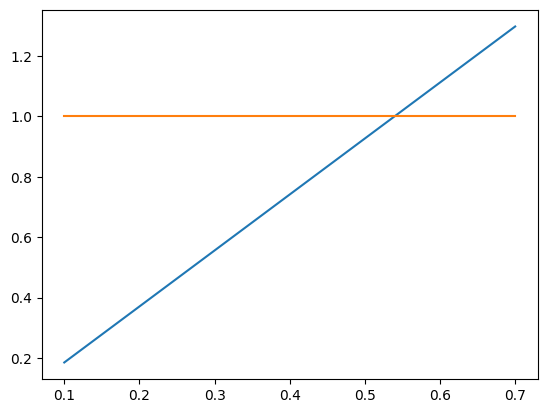

In [19]:
import pint
ureg = pint.UnitRegistry()
import numpy as np
import matplotlib.pyplot as plt
Q_ = ureg.Quantity





M_cruise = np.linspace(0.1,0.7,8)
a_ref = Q_(330,'m/s')
rho_ref = Q_(1.18,'kg/m^3')


U_cruise = a_ref*M_cruise

inlet_ID = Q_(6.5,'cm')
inlet_OD = Q_(8.8,'cm')
outlet_ID = Q_(4.7,'cm')
shroud_OD = Q_(11.5,'cm')
A_shroud = 0.25 * np.pi * shroud_OD**2
C_drag = 0.05
A_inlet = 0.25 * np.pi * (inlet_OD**2 )

F_drag = 0.5 * rho_ref * (U_cruise ** 2) * A_shroud
m_dot_in = rho_ref*U_cruise*A_inlet
delta_U = F_drag/m_dot_in
U_out = U_cruise + delta_U
M_out = U_out/a_ref
A_out = m_dot_in/(rho_ref*U_out)
print(A_out)
outlet_OD = np.sqrt(outlet_ID**2 + 4*A_out/np.pi)
print(F_drag.to('N'),m_dot_in.to('kg/s'), U_out.to('m/s'))
print(outlet_OD.to('cm'),outlet_OD/shroud_OD)

#plt.plot(M_cruise,F_drag.to('N'))
#plt.plot(M_cruise,m_dot_in.to('kg/s'))
#plt.plot(M_cruise,U_out.to('m/s'))
plt.plot(M_cruise,M_out)
plt.plot(M_cruise,np.ones_like(M_cruise))
